
📈 RESULTS
 Rank-1 Accuracy: 53.95%
 Rank-3 Accuracy: 80.26%
----------------------------------------
 EER (Equal Error Rate): 27.30%
----------------------------------------
 At treshold of (0.17):
    FAR: 16.37%
    FRR: 34.87%
----------------------------------------
 ZeroFAR FRR: 98.36%
 ZeroFRR FAR: 90.38%
💾 Grafici salvati: live_metrics_report_no_auc.png


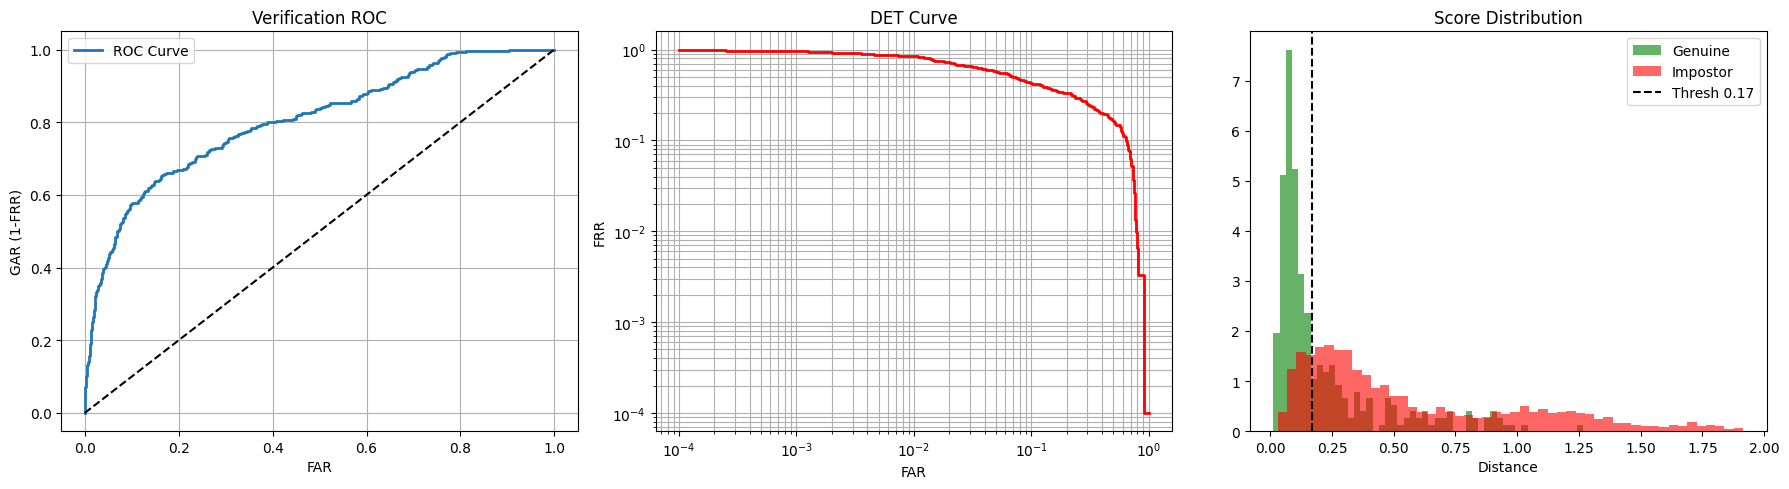

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, glob
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

#CONFIGURAZIONE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "/kaggle/input/processed-keypoints-yolo/processed_gait_multiangle"
MODEL_PATH = "/kaggle/input/preprocessing-yolo/gait_resnet_best.pth"
TARGET_LEN = 60

#ARCHITETTURA 
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p); self.eps = eps
    def forward(self, x): return F.avg_pool1d(x.clamp(min=self.eps).pow(self.p), (x.size(-1))).pow(1./self.p)

class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.bn1 = nn.InstanceNorm2d(out_c, affine=True) 
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=(3, 1), padding=(1, 0), bias=False)
        self.bn2 = nn.InstanceNorm2d(out_c, affine=True)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=(3, 1), padding=(1, 0), bias=False)
        self.shortcut = nn.Sequential()
        if in_c != out_c: self.shortcut = nn.Sequential(nn.Conv2d(in_c, out_c, kernel_size=1, bias=False), nn.InstanceNorm2d(out_c, affine=True))
    def forward(self, x): return F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))) + self.shortcut(x))

class GaitResNet(nn.Module):
    def __init__(self, in_channels=4, embedding_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.bn1 = nn.InstanceNorm2d(64, affine=True)
        self.layer1 = BasicBlock(64, 64); self.layer2 = BasicBlock(64, 128); self.layer3 = BasicBlock(128, 256)
        self.gem = GeM()
        self.bn_head = nn.BatchNorm1d(256 * 17)
        self.fc = nn.Linear(256 * 17, embedding_dim, bias=False)
        self.bn_out = nn.BatchNorm1d(embedding_dim)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        B, C, T, V = x.shape
        x = x.permute(0, 1, 3, 2).contiguous().view(B, C*V, T) 
        x = self.gem(x).view(B, -1)
        x = self.bn_head(x) 
        return self.bn_out(self.fc(x))

#DATASET
class GaitTestDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        for angle in ["0", "45", "90"]:
            dirp = os.path.join(root_dir, angle, "test")
            if not os.path.isdir(dirp): continue
            for f in glob.glob(os.path.join(dirp, "*.npy")):
                pid = os.path.basename(f).rsplit('_', 2)[0]
                self.samples.append((f, pid))
        self.pid_to_files = {}
        for f, pid in self.samples: self.pid_to_files.setdefault(pid, []).append(f)
        self.pids = sorted(list(self.pid_to_files.keys()))
        self.pid_to_idx = {pid: i for i, pid in enumerate(self.pids)}

    def _get_features(self, path):
        kp_all = np.load(path).astype(np.float32)
        for t in range(1, kp_all.shape[0]):
            mask = (kp_all[t, :, 0] == 0) & (kp_all[t, :, 1] == 0)
            if np.any(mask): kp_all[t, mask] = kp_all[t-1, mask]
        T_orig = kp_all.shape[0]
        idxs = np.linspace(0, T_orig-1, TARGET_LEN)
        kp_interp = np.zeros((TARGET_LEN, 17, 3), dtype=np.float32)
        for k in range(17):
            for c in range(3): kp_interp[:, k, c] = np.interp(idxs, np.arange(T_orig), kp_all[:, k, c])
        kp_final = kp_interp[:, :, :2]
        hips = (kp_final[:, 11, :2] + kp_final[:, 12, :2]) / 2.0
        ankles = (kp_final[:, 15, :2] + kp_final[:, 16, :2]) / 2.0
        heights = np.linalg.norm(kp_final[:, 0, :2] - ankles, axis=1)
        avg_height = np.median(heights[heights > 10]) if np.any(heights > 10) else 1.0
        center_x_per_frame = hips[:, 0]
        center_y_global = np.mean(hips[:, 1])
        centers = np.stack([center_x_per_frame, np.full(TARGET_LEN, center_y_global)], axis=1)
        kp_xy = (kp_final - centers[:, None, :]) / (avg_height + 1e-6)
        vel = np.diff(kp_xy, axis=0, prepend=kp_xy[:1])
        return torch.from_numpy(np.concatenate([kp_xy, vel], axis=2).transpose(2, 0, 1)).float()

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, pid = self.samples[idx]
        return self._get_features(path), self.pid_to_idx[pid]

#CALCOLO METRICHE
def calculate_live_metrics():
    
    ds = GaitTestDataset(DATA_ROOT)
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    
    model = GaitResNet().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    
    # Estrazione Features
    feats_list, labels_list = [], []
    with torch.no_grad():
        for x, lbl in loader:
            x = x.to(DEVICE)
            # TTA
            x_flip = x.clone()
            x_flip[:, 0, :, :] *= -1; x_flip[:, 2, :, :] *= -1
            emb = (model(x) + model(x_flip)) / 2.0
            # PowerNorm
            emb = torch.sign(emb) * torch.sqrt(torch.abs(emb) + 1e-12)
            emb = F.normalize(emb, p=2, dim=1)
            
            feats_list.append(emb.cpu())
            labels_list.append(lbl)
            
    feats = torch.cat(feats_list)
    labels = torch.cat(labels_list)
    unique_ids = torch.unique(labels).numpy()
    
    # Costruzione Gallery (Centroidi) e Probe
    gallery_centroids = []
    gallery_labels = []
    probe_feats = []
    probe_labels = []
    
    for uid in unique_ids:
        idxs = (labels == uid).nonzero(as_tuple=True)[0]
        if len(idxs) < 2: continue
        
        split = len(idxs) // 2
        # Enrollment (50%)
        centroid = torch.mean(feats[idxs[:split]], dim=0, keepdim=True)
        centroid = F.normalize(centroid, p=2, dim=1)
        gallery_centroids.append(centroid)
        gallery_labels.append(uid)
        
        # Probe (50%)
        probe_feats.append(feats[idxs[split:]])
        probe_labels.append(labels[idxs[split:]])
        
    gallery_centroids = torch.cat(gallery_centroids)
    gallery_labels = np.array(gallery_labels)
    probe_feats = torch.cat(probe_feats)
    probe_labels = torch.cat(probe_labels)
    
    # Matrice Distanze (Probe vs Gallery)
    d_mat = 1.0 - torch.matmul(probe_feats, gallery_centroids.t())
    
    # Estrazione Score Genuine e Impostor
    genuine_scores = []
    impostor_scores = []
    ranks = []
    
    for i in range(len(probe_labels)):
        p_lbl = probe_labels[i].item()
        true_col_idx = np.where(gallery_labels == p_lbl)[0]
        if len(true_col_idx) == 0: continue 
        true_col_idx = true_col_idx[0]
        
        dists = d_mat[i].numpy()
        
        # Genuine & Impostor Scores
        gen_score = dists[true_col_idx]
        genuine_scores.append(gen_score)
        mask = np.ones(len(dists), dtype=bool)
        mask[true_col_idx] = False
        impostor_scores.extend(dists[mask])
        
        # Rank
        sorted_indices = np.argsort(dists)
        sorted_labels = gallery_labels[sorted_indices]
        rank_pos = np.where(sorted_labels == p_lbl)[0][0]
        ranks.append(rank_pos + 1)

    genuine_scores = np.array(genuine_scores)
    impostor_scores = np.array(impostor_scores)
    ranks = np.array(ranks)
    
    # Calcolo Metriche
    y_true = np.concatenate([np.ones(len(genuine_scores)), np.zeros(len(impostor_scores))])
    y_scores = np.concatenate([-genuine_scores, -impostor_scores])
    
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    
    # EER
    eer = brentq(lambda x : 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    
    # ZeroFAR / ZeroFRR
    zero_far_idx = np.where(fpr <= 0.0001)[0][-1] 
    zero_far_frr = fnr[zero_far_idx]
    
    zero_frr_idx = np.where(fnr <= 0.0001)[0][0]
    zero_frr_far = fpr[zero_frr_idx]
    
    
    MY_THRESHOLD = 0.17
    my_frr = np.mean(genuine_scores > MY_THRESHOLD) * 100
    my_far = np.mean(impostor_scores <= MY_THRESHOLD) * 100
    
    # Rank Accuracy
    r1 = np.mean(ranks == 1) * 100
    r3 = np.mean(ranks <= 3) * 100

    print("\n" + "="*40)
    print("📈 RESULTS")
    print("="*40)
    print(f" Rank-1 Accuracy: {r1:.2f}%")
    print(f" Rank-3 Accuracy: {r3:.2f}%")
    print("-" * 40)
    print(f" EER (Equal Error Rate): {eer*100:.2f}%")
    print("-" * 40)
    print(f" At treshold of (0.17):")
    print(f"    FAR: {my_far:.2f}%")
    print(f"    FRR: {my_frr:.2f}%")
    print("-" * 40)
    print(f" ZeroFAR FRR: {zero_far_frr*100:.2f}%")
    print(f" ZeroFRR FAR: {zero_frr_far*100:.2f}%")
    
    # Plotting
    plt.figure(figsize=(18, 5))
    
    # ROC
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, lw=2, label='ROC Curve')
    plt.plot([0,1],[0,1], 'k--')
    plt.title('Verification ROC')
    plt.xlabel('FAR'); plt.ylabel('GAR (1-FRR)')
    plt.grid()
    plt.legend()
    
    # DET (Log scale)
    plt.subplot(1, 3, 2)
    plt.loglog(np.clip(fpr, 1e-4, 1), np.clip(fnr, 1e-4, 1), lw=2, color='red')
    plt.title('DET Curve')
    plt.xlabel('FAR'); plt.ylabel('FRR')
    plt.grid(True, which="both")
    
    # Histogram
    plt.subplot(1, 3, 3)
    plt.hist(genuine_scores, bins=50, alpha=0.6, label='Genuine', density=True, color='green')
    plt.hist(impostor_scores, bins=50, alpha=0.6, label='Impostor', density=True, color='red')
    plt.axvline(MY_THRESHOLD, color='black', linestyle='--', label=f'Thresh {MY_THRESHOLD}')
    plt.title('Score Distribution')
    plt.xlabel('Distance')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig("live_metrics_report_no_auc.png")
    print("💾 Grafici salvati: live_metrics_report_no_auc.png")

if __name__ == "__main__":
    calculate_live_metrics()

 Estrazione e Preparazione Dati...
📊 Gallery: 7 Centroidi
🎥 Probe: 450 Tentativi

--- ANALISI IMPATTO MARGINE (Soglia Distanza Fissa: 0.17) ---
Margine    | FAR (Intrusi)   | FRR (Rifiuti)   | DIR (Successo) 
-----------------------------------------------------------------
0.00       | 53.77         % | 50.63         % | 49.37         %
0.01       | 46.92         % | 54.43         % | 45.57         %
0.02       | 37.67         % | 56.96         % | 43.04         %
0.03       | 30.82         % | 62.66         % | 37.34         %
0.04       | 25.34         % | 65.19         % | 34.81         %
0.05       | 21.58         % | 67.09         % | 32.91         %
0.08       | 10.96         % | 80.38         % | 19.62         %
0.10       | 4.79          % | 84.81         % | 15.19         %

 Grafico salvato: margin_impact_chart.png


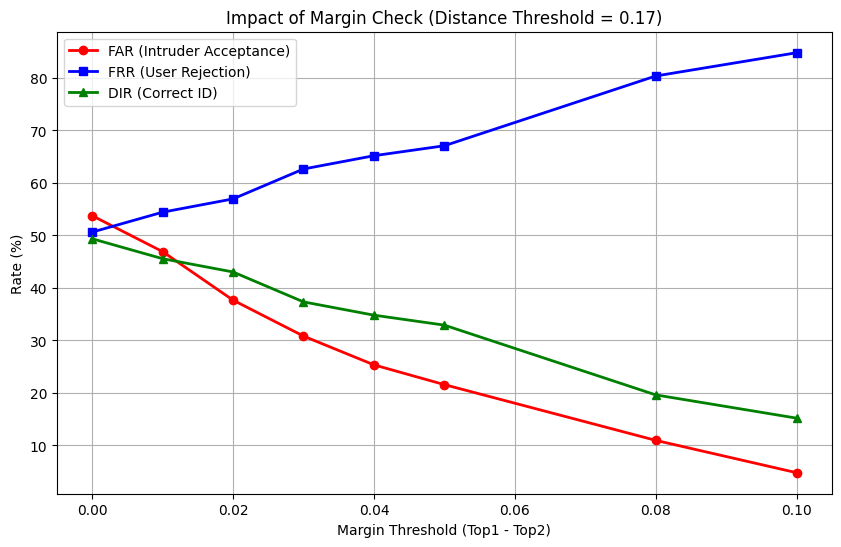

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os, glob
import matplotlib.pyplot as plt

#CONFIGURAZIONE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "/kaggle/input/processed-keypoints-yolo/processed_gait_multiangle"
MODEL_PATH = "/kaggle/input/preprocessing-yolo/gait_resnet_best.pth"
TARGET_LEN = 60
FIXED_DIST_THRESH = 0.17

# ARCHITETTURA & DATASET 
class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super().__init__()
        self.p = nn.Parameter(torch.ones(1) * p); self.eps = eps
    def forward(self, x): return F.avg_pool1d(x.clamp(min=self.eps).pow(self.p), (x.size(-1))).pow(1./self.p)

class BasicBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.bn1 = nn.InstanceNorm2d(out_c, affine=True) 
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size=(3, 1), padding=(1, 0), bias=False)
        self.bn2 = nn.InstanceNorm2d(out_c, affine=True)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size=(3, 1), padding=(1, 0), bias=False)
        self.shortcut = nn.Sequential()
        if in_c != out_c: self.shortcut = nn.Sequential(nn.Conv2d(in_c, out_c, kernel_size=1, bias=False), nn.InstanceNorm2d(out_c, affine=True))
    def forward(self, x): return F.relu(self.bn2(self.conv2(F.relu(self.bn1(self.conv1(x))))) + self.shortcut(x))

class GaitResNet(nn.Module):
    def __init__(self, in_channels=4, embedding_dim=256):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=(3, 3), padding=(1, 1), bias=False)
        self.bn1 = nn.InstanceNorm2d(64, affine=True)
        self.layer1 = BasicBlock(64, 64); self.layer2 = BasicBlock(64, 128); self.layer3 = BasicBlock(128, 256)
        self.gem = GeM()
        self.bn_head = nn.BatchNorm1d(256 * 17)
        self.fc = nn.Linear(256 * 17, embedding_dim, bias=False)
        self.bn_out = nn.BatchNorm1d(embedding_dim)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x)
        B, C, T, V = x.shape
        x = x.permute(0, 1, 3, 2).contiguous().view(B, C*V, T) 
        x = self.gem(x).view(B, -1)
        x = self.bn_head(x) 
        return self.bn_out(self.fc(x))

class GaitTestDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        for angle in ["0", "45", "90"]:
            dirp = os.path.join(root_dir, angle, "test")
            if not os.path.isdir(dirp): continue
            for f in glob.glob(os.path.join(dirp, "*.npy")):
                pid = os.path.basename(f).rsplit('_', 2)[0]
                self.samples.append((f, pid))
        self.pid_to_files = {}
        for f, pid in self.samples: self.pid_to_files.setdefault(pid, []).append(f)
        self.pids = sorted(list(self.pid_to_files.keys()))
        self.pid_to_idx = {pid: i for i, pid in enumerate(self.pids)}
    def _get_features(self, path):
        kp_all = np.load(path).astype(np.float32)
        for t in range(1, kp_all.shape[0]):
            mask = (kp_all[t, :, 0] == 0) & (kp_all[t, :, 1] == 0)
            if np.any(mask): kp_all[t, mask] = kp_all[t-1, mask]
        T_orig = kp_all.shape[0]
        idxs = np.linspace(0, T_orig-1, TARGET_LEN)
        kp_interp = np.zeros((TARGET_LEN, 17, 3), dtype=np.float32)
        for k in range(17):
            for c in range(3): kp_interp[:, k, c] = np.interp(idxs, np.arange(T_orig), kp_all[:, k, c])
        kp_final = kp_interp[:, :, :2]
        hips = (kp_final[:, 11, :2] + kp_final[:, 12, :2]) / 2.0
        ankles = (kp_final[:, 15, :2] + kp_final[:, 16, :2]) / 2.0
        heights = np.linalg.norm(kp_final[:, 0, :2] - ankles, axis=1)
        avg_height = np.median(heights[heights > 10]) if np.any(heights > 10) else 1.0
        center_x_per_frame = hips[:, 0]
        center_y_global = np.mean(hips[:, 1])
        centers = np.stack([center_x_per_frame, np.full(TARGET_LEN, center_y_global)], axis=1)
        kp_xy = (kp_final - centers[:, None, :]) / (avg_height + 1e-6)
        vel = np.diff(kp_xy, axis=0, prepend=kp_xy[:1])
        return torch.from_numpy(np.concatenate([kp_xy, vel], axis=2).transpose(2, 0, 1)).float()
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, pid = self.samples[idx]
        return self._get_features(path), self.pid_to_idx[pid]

#TEST
def test_margin_impact():
    print(" Estrazione e Preparazione Dati...")
    ds = GaitTestDataset(DATA_ROOT)
    loader = DataLoader(ds, batch_size=64, shuffle=False)
    
    model = GaitResNet().to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    
    feats_list, labels_list = [], []
    with torch.no_grad():
        for x, lbl in loader:
            x = x.to(DEVICE)
            x_flip = x.clone()
            x_flip[:, 0, :, :] *= -1; x_flip[:, 2, :, :] *= -1
            emb = (model(x) + model(x_flip)) / 2.0
            emb = torch.sign(emb) * torch.sqrt(torch.abs(emb) + 1e-12)
            emb = F.normalize(emb, p=2, dim=1)
            feats_list.append(emb.cpu())
            labels_list.append(lbl)
            
    feats = torch.cat(feats_list)
    labels = torch.cat(labels_list)
    unique_ids = torch.unique(labels).numpy()
    
    # Setup Gallery (Centroidi) e Probe
    gal_feats, gal_lbls = [], []
    prb_feats, prb_lbls = [], []
    
    # Divisione Registrati (Gallery) vs Intrusi
    # Usiamo 7 persone come "Registrate" e 7 come "Intruse"
    reg_ids = unique_ids[:7]
    
    for uid in unique_ids:
        idxs = (labels == uid).nonzero(as_tuple=True)[0]
        if len(idxs) < 2: continue
        
        # Se è registrato, crea centroide e metti in gallery
        if uid in reg_ids:
            split = len(idxs) // 2
            centroid = torch.mean(feats[idxs[:split]], dim=0, keepdim=True)
            centroid = F.normalize(centroid, p=2, dim=1)
            gal_feats.append(centroid)
            gal_lbls.append(uid)
            # Il resto è probe (genuine attempt)
            prb_feats.append(feats[idxs[split:]])
            prb_lbls.append(labels[idxs[split:]])
        else:
            # Se è intruso, TUTTI i video sono probe (impostor attempt)
            prb_feats.append(feats[idxs])
            prb_lbls.append(labels[idxs])
            
    gal_feats = torch.cat(gal_feats)
    gal_lbls = np.array(gal_lbls)
    prb_feats = torch.cat(prb_feats)
    prb_lbls = torch.cat(prb_lbls)
    
    print(f"📊 Gallery: {len(gal_feats)} Centroidi")
    print(f"🎥 Probe: {len(prb_feats)} Tentativi")
    
    # Calcolo Distanze
    d_mat = 1.0 - torch.matmul(prb_feats, gal_feats.t())
    
    
    # SWEEP SUL MARGINE
    margins = [0.00, 0.01, 0.02, 0.03, 0.04, 0.05, 0.08, 0.10]
    
    far_list = []
    frr_list = []
    dir_list = []
    
    print(f"\n--- ANALISI IMPATTO MARGINE (Soglia Distanza Fissa: {FIXED_DIST_THRESH}) ---")
    print(f"{'Margine':<10} | {'FAR (Intrusi)':<15} | {'FRR (Rifiuti)':<15} | {'DIR (Successo)':<15}")
    print("-" * 65)
    
    for m in margins:
        false_accepts = 0
        false_rejects = 0
        correct_identify = 0
        
        n_impostors = 0
        n_genuine = 0
        
        for i in range(len(prb_lbls)):
            true_lbl = prb_lbls[i].item()
            dists = d_mat[i]
            
            # Top-2
            vals, idxs = torch.topk(dists, k=2, largest=False)
            best_dist = vals[0].item()
            best_lbl = gal_lbls[idxs[0].item()]
            
            # Calcolo margine
            if len(vals) > 1:
                margin_val = vals[1].item() - vals[0].item()
            else:
                margin_val = 1.0 
            
            is_registered = true_lbl in reg_ids
            
            
            accepted = (best_dist <= FIXED_DIST_THRESH) and (margin_val >= m)
            
            if is_registered:
                n_genuine += 1
                if accepted:
                    if best_lbl == true_lbl:
                        correct_identify += 1
                    else:
                        false_rejects += 1 
                else:
                    false_rejects += 1 
            else:
                n_impostors += 1
                if accepted:
                    false_accepts += 1 
                    
        far = (false_accepts / n_impostors) * 100
        frr = (false_rejects / n_genuine) * 100
        dir_rate = (correct_identify / n_genuine) * 100
        
        far_list.append(far)
        frr_list.append(frr)
        dir_list.append(dir_rate)
        
        print(f"{m:<10.2f} | {far:<14.2f}% | {frr:<14.2f}% | {dir_rate:<14.2f}%")

    
    plt.figure(figsize=(10, 6))
    plt.plot(margins, far_list, 'r-o', linewidth=2, label='FAR (Intruder Acceptance)')
    plt.plot(margins, frr_list, 'b-s', linewidth=2, label='FRR (User Rejection)')
    plt.plot(margins, dir_list, 'g-^', linewidth=2, label='DIR (Correct ID)')
    
    plt.title(f'Impact of Margin Check (Distance Threshold = {FIXED_DIST_THRESH})')
    plt.xlabel('Margin Threshold (Top1 - Top2)')
    plt.ylabel('Rate (%)')
    plt.grid(True)
    plt.legend()
    plt.savefig("margin_impact_chart.png")
    print("\n Grafico salvato: margin_impact_chart.png")

if __name__ == "__main__":
    test_margin_impact()